In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv('Cleaning_data_merged.csv')
print(f"Dataset loaded: {df.shape}")
print(f"\nRelevant columns for diabetes classification:")
print(f"  DIQ010: {df['DIQ010'].notna().sum()} non-null values")
print(f"  DIQ160: {df['DIQ160'].notna().sum()} non-null values")
print(f"  LBXGH:  {df['LBXGH'].notna().sum()} non-null values")


Dataset loaded: (11933, 98)

Relevant columns for diabetes classification:
  DIQ010: 11740 non-null values
  DIQ160: 8022 non-null values
  LBXGH:  6715 non-null values


In [88]:
absolute_no_diabetes = ((df['DIQ010'] == 2.0) & (df['LBXGH'] < 5.7)) | \
                       ((df['DIQ160'] == 2.0) & (df['LBXGH'] < 5.7))
df.loc[absolute_no_diabetes, 'diagnostic_category'] = 'Absolute No Diabetes'
print(f"Absolute No Diabetes: {absolute_no_diabetes.sum()}")

Absolute No Diabetes: 4222


In [89]:
# Initialize new category column
df['diagnostic_category'] = 'Unclassified'

# ============================================================================
# 1. ABSOLUTE DIAGNOSED DIABETES
# DIQ010 = 1 (Yes) & LBXGH ≥ 6.5
# ============================================================================
absolute_diagnosed = (df['DIQ010'] == 1.0) & (df['LBXGH'] >= 6.5)
df.loc[absolute_diagnosed, 'diagnostic_category'] = 'Absolute Diagnosed Diabetes'
print(f"Absolute Diagnosed Diabetes: {absolute_diagnosed.sum()}")

# ============================================================================
# 2. ABSOLUTE DIAGNOSED PRE-DIABETES
# DIQ160 = 1 (Yes) & LBXGH between 5.7-6.49
# ============================================================================
absolute_prediabetes = (df['DIQ160'] == 1.0) & (df['LBXGH'] >= 5.7) & (df['LBXGH'] < 6.5)
df.loc[absolute_prediabetes, 'diagnostic_category'] = 'Absolute Diagnosed Pre-Diabetes'
print(f"Absolute Diagnosed Pre-Diabetes: {absolute_prediabetes.sum()}")

# ============================================================================
# 3. ABSOLUTE NO DIABETES
# (DIQ010 = 2 (No) & LBXGH < 5.7) OR (DIQ160 = 2 (No) & LBXGH < 5.7)
# ============================================================================
absolute_no_diabetes = ((df['DIQ010'] == 2.0) & (df['LBXGH'] < 5.7)) | \
                       ((df['DIQ160'] == 2.0) & (df['LBXGH'] < 5.7))
df.loc[absolute_no_diabetes, 'diagnostic_category'] = 'Absolute No Diabetes'
print(f"Absolute No Diabetes: {absolute_no_diabetes.sum()}")

# ============================================================================
# 4. WRONGLY DIAGNOSED (Misclassification/Discordance)
# Multiple conditions for diagnostic mismatch
# ============================================================================
wrongly_diagnosed = (
    # DIQ010 = 1 (YES) & LBXGH < 6.5 (diagnosed but no biomarker evidence)
    ((df['DIQ010'] == 1.0) & (df['LBXGH'] < 6.5)) |
    # DIQ010 = 2 (No) & LBXGH > 5.7 (denies diabetes but has biomarker)
    ((df['DIQ010'] == 2.0) & (df['LBXGH'] > 6.5)) |
    # DIQ010 = 3 (Borderline) & (LBXGH < 5.7 OR LBXGH > 6.49) (uncertain with mismatched biomarker)
    ((df['DIQ010'] == 3.0) & ((df['LBXGH'] < 5.7) | (df['LBXGH'] > 6.49))) |
    # DIQ160 = 1 (YES) & (LBXGH < 5.7 OR LBXGH > 6.49) (pre-diabetes reported but biomarker mismatches)
    ((df['DIQ160'] == 1.0) & ((df['LBXGH'] < 5.7) | (df['LBXGH'] > 6.49))) |
    # DIQ160 = 2 (No) & (5.7 <= LBXGH < 6.5) (denies pre-diabetes but HbA1c in pre-diabetes range)
    ((df['DIQ160'] == 2.0) & ((df['LBXGH'] > 5.7)))
)
df.loc[wrongly_diagnosed, 'diagnostic_category'] = 'Wrongly Diagnosed'
print(f"Wrongly Diagnosed: {wrongly_diagnosed.sum()}")

# print("\n" + "=" * 70)
# print("Diagnostic Categories Created")
# print("=" * 70)
# print(f"\nCategory Distribution:")
# print(df['diagnostic_category'].value_counts())
# print(f"\nProportions:")
# print(df['diagnostic_category'].value_counts(normalize=True).round(4))


Absolute Diagnosed Diabetes: 569
Absolute Diagnosed Pre-Diabetes: 366
Absolute No Diabetes: 4222
Wrongly Diagnosed: 1413


In [90]:
# Check for overlaps and unclassified records
print("=" * 70)
print("VALIDATION CHECK")
print("=" * 70)

unclassified = (df['diagnostic_category'] == 'Unclassified').sum()
print(f"\nUnclassified records: {unclassified:,}")

if unclassified > 0:
    print("\nSample of unclassified records:")
    print(df[df['diagnostic_category'] == 'Unclassified'][['DIQ010', 'DIQ160', 'LBXGH', 'diagnostic_category']].head(10))

# Verify no overlaps (each row should have exactly one category)
total = len(df)
categorized = (df['diagnostic_category'] != 'Unclassified').sum()
print(f"\nTotal records: {total:,}")
print(f"Categorized: {categorized:,}")
print(f"Coverage: {100*categorized/total:.1f}%")

VALIDATION CHECK

Unclassified records: 5,662

Sample of unclassified records:
    DIQ010  DIQ160  LBXGH diagnostic_category
3      2.0     NaN    NaN        Unclassified
4      2.0     NaN    NaN        Unclassified
5      2.0     NaN    NaN        Unclassified
6      2.0     2.0    NaN        Unclassified
7      2.0     1.0    NaN        Unclassified
21     2.0     2.0    5.7        Unclassified
23     2.0     2.0    NaN        Unclassified
26     2.0     2.0    5.7        Unclassified
27     2.0     NaN    NaN        Unclassified
32     2.0     2.0    NaN        Unclassified

Total records: 11,933
Categorized: 6,271
Coverage: 52.6%


In [91]:
# Remove Unclassified records
print("=" * 70)
print("REMOVING UNCLASSIFIED RECORDS")
print("=" * 70)

# before_count = len(df)
# df = df[df['diagnostic_category'] != 'Unclassified'].copy()
# after_count = len(df)
# removed = before_count - after_count

# print(f"\nBefore: {before_count:,} records")
# print(f"After:  {after_count:,} records")
# print(f"Removed: {removed:,} records ({100*removed/before_count:.2f}%)")

print("\nFinal Category Distribution:")
print(df['diagnostic_category'].value_counts())
print(f"\nFinal Proportions:")
print(df['diagnostic_category'].value_counts(normalize=True).round(4))

REMOVING UNCLASSIFIED RECORDS

Final Category Distribution:
diagnostic_category
Unclassified                       5662
Absolute No Diabetes               3923
Wrongly Diagnosed                  1413
Absolute Diagnosed Diabetes         569
Absolute Diagnosed Pre-Diabetes     366
Name: count, dtype: int64

Final Proportions:
diagnostic_category
Unclassified                       0.4745
Absolute No Diabetes               0.3288
Wrongly Diagnosed                  0.1184
Absolute Diagnosed Diabetes        0.0477
Absolute Diagnosed Pre-Diabetes    0.0307
Name: proportion, dtype: float64


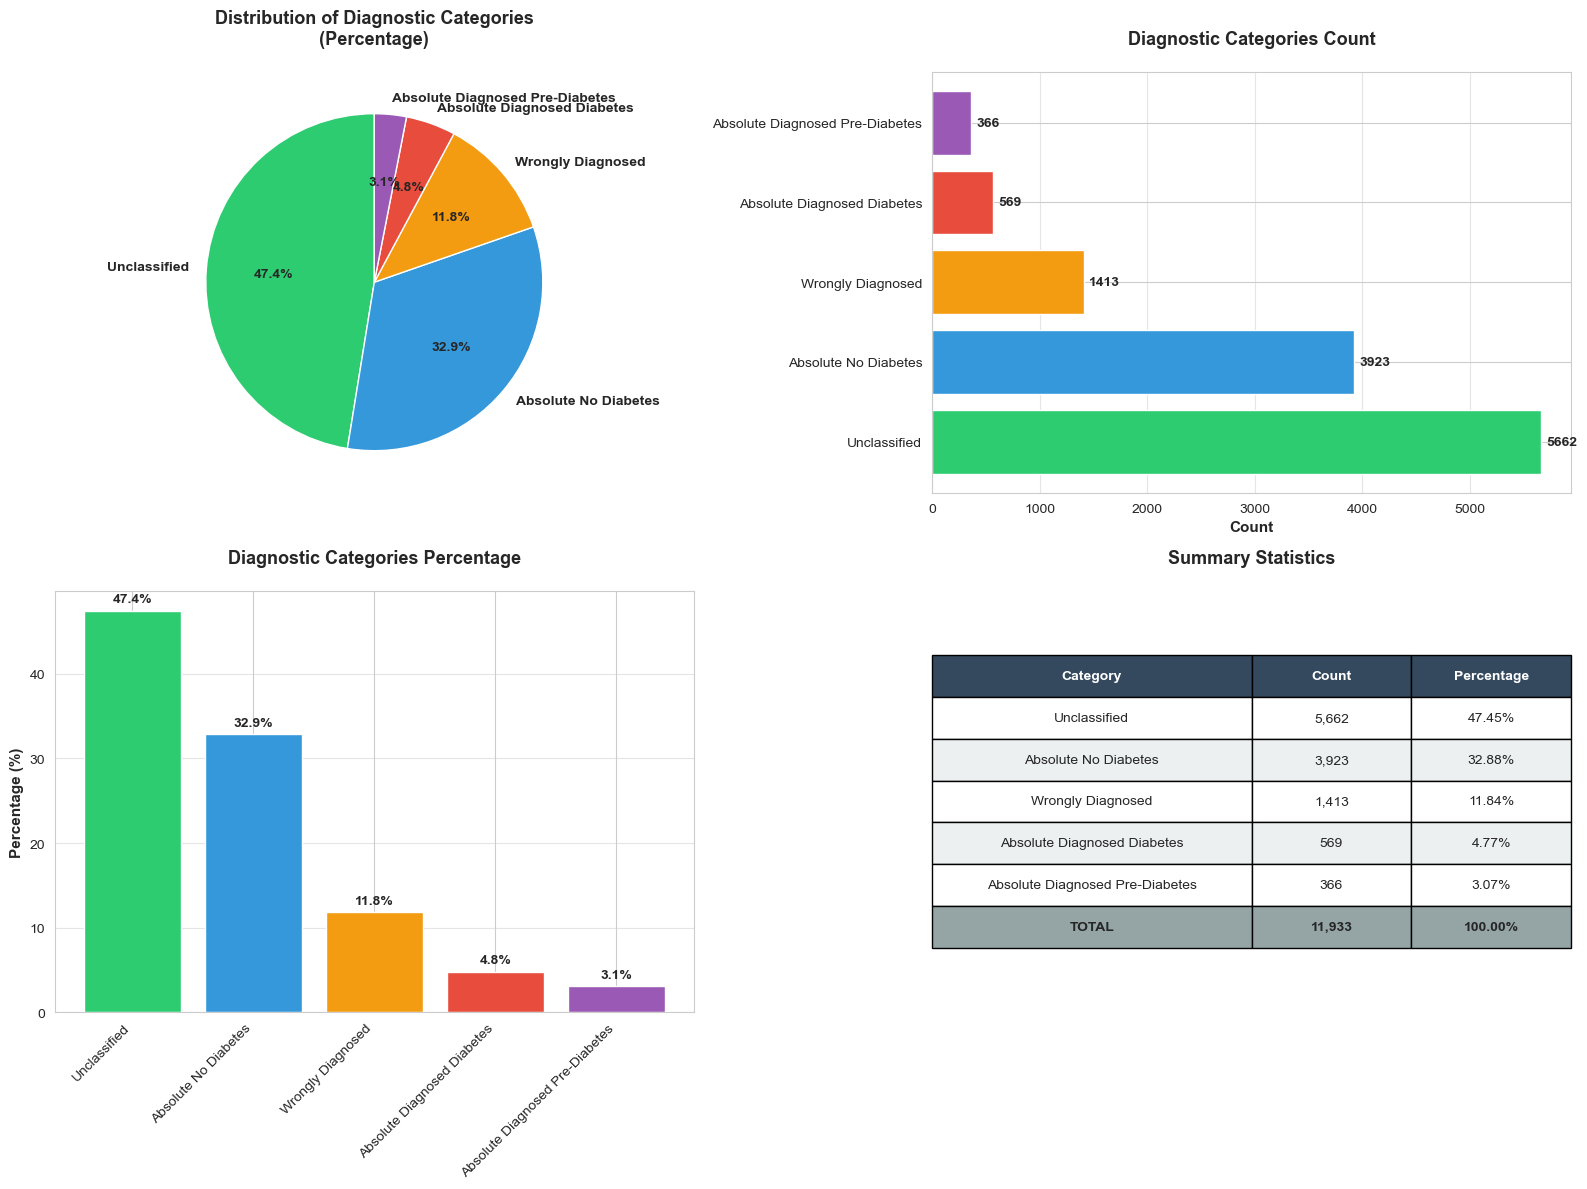


Plot saved as 'diagnostic_categories_plot.png'

DIAGNOSTIC CATEGORIES SUMMARY
  Unclassified............................  5,662 ( 47.45%)
  Absolute No Diabetes....................  3,923 ( 32.88%)
  Wrongly Diagnosed.......................  1,413 ( 11.84%)
  Absolute Diagnosed Diabetes.............    569 (  4.77%)
  Absolute Diagnosed Pre-Diabetes.........    366 (  3.07%)
  TOTAL................................... 11,933 (100.00%)


In [92]:
# Visualize the distribution with pie chart, bar chart, and summary statistics
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Get category counts
category_counts = df['diagnostic_category'].value_counts()
category_proportions = df['diagnostic_category'].value_counts(normalize=True) * 100

# Create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Color palette
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c', '#e67e22', '#2c3e50']

# 1. Pie chart (top-left)
ax1 = axes[0, 0]
wedges, texts, autotexts = ax1.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax1.set_title('Distribution of Diagnostic Categories\n(Percentage)', fontsize=13, fontweight='bold', pad=20)

# 2. Horizontal bar chart with counts (top-right)
ax2 = axes[0, 1]
y_pos = range(len(category_counts))
ax2.barh(y_pos, category_counts.values, color=colors)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(category_counts.index)
ax2.set_xlabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Diagnostic Categories Count', fontsize=13, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.5)
# Add count labels on bars
for i, v in enumerate(category_counts.values):
    ax2.text(v + 50, i, str(v), va='center', fontweight='bold')

# 3. Bar chart with percentages (bottom-left)
ax3 = axes[1, 0]
x_pos = range(len(category_proportions))
bars = ax3.bar(x_pos, category_proportions.values, color=colors)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(category_proportions.index, rotation=45, ha='right')
ax3.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax3.set_title('Diagnostic Categories Percentage', fontsize=13, fontweight='bold', pad=20)
ax3.grid(axis='y', alpha=0.5)
# Add percentage labels on bars
for i, v in enumerate(category_proportions.values):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# 4. Summary statistics table (bottom-right)
ax4 = axes[1, 1]
ax4.axis('off')

# Prepare summary data
summary_data = []
for category in category_counts.index:
    count = category_counts[category]
    pct = category_proportions[category]
    summary_data.append([category, f'{count:,}', f'{pct:.2f}%'])

# Add total row
summary_data.append(['TOTAL', f'{len(df):,}', '100.00%'])

# Create table
table = ax4.table(cellText=summary_data, 
                  colLabels=['Category', 'Count', 'Percentage'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.5, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style the header
for i in range(3):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    for j in range(3):
        if i == len(summary_data):  # Total row
            table[(i, j)].set_facecolor('#95a5a6')
            table[(i, j)].set_text_props(weight='bold')
        elif i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax4.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('diagnostic_categories_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'diagnostic_categories_plot.png'")
print("\n" + "="*70)
print("DIAGNOSTIC CATEGORIES SUMMARY")
print("="*70)
for category in category_counts.index:
    count = category_counts[category]
    pct = category_proportions[category]
    print(f"  {category:.<40} {count:>6,} ({pct:>6.2f}%)")
print("="*70)
print(f"  {'TOTAL':.<40} {len(df):>6,} (100.00%)")
print("="*70)